In [20]:
# Import libraries + load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [21]:
# Task 1: Identify data quality issues

# 1. Data type mismatch
df.dtypes # The values are stored as object or numerical (int64)

# 2. Missing values
df.isna().sum() # There are missing values in Teacher_Quality, Parental_Education_Level, and Distance_from_Home

# 3. Number of rows with missing values
df[df.isna().any(axis=1)].shape[0] # We have 229 rows with missing values, out of 6607 rows.

229

In [22]:
# Task 2: Apply missing value strategies, and why we chose this strategy

# While we can do mode imputation (since the missing values are categorical), we can also remove them seeing as the number of rows is neglible (229 out of 6607 is about 3.5%).
df_remove = df.dropna()
df_remove.shape # Now we have 6378 rows

(6378, 20)

In [23]:
# Task 3: Detecting and handling outliers

# Ensure df_remove is defined
df_remove = df.dropna().copy()

# Part 1 - Detection -----------------------------
# Identify numerical columns for outlier detection
numerical_cols = df_remove.select_dtypes(include=np.number).columns.tolist()

print(f"Numerical columns identified for outlier detection: {numerical_cols}")

# Function to detect outliers using IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detect and display outliers for each numerical column
print("\nOutliers detected using IQR method:")
for col in numerical_cols:
    outliers, _, _ = detect_outliers_iqr(df_remove, col)
    if not outliers.empty:
        print(f"\n--- Outliers in {col} ---")
        print(outliers[[col]]) # Display only the outlier column
    else:
        print(f"\nNo outliers detected in {col}")

Numerical columns identified for outlier detection: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']

Outliers detected using IQR method:

--- Outliers in Hours_Studied ---
      Hours_Studied
209              43
262               1
478              38
1061              3
1101              3
1539              3
1615             39
1957             39
2024              2
2035             37
2305             39
2506             38
2521             38
2895             44
2947              2
3017              3
3152              3
3241             37
3454              2
3716             39
3982             39
4033              3
4047             37
4198              2
4207              3
4617              3
4635              3
4639              3
4725              1
4779              1
4784             37
4870             38
5157             38
5224             38
5642              3
5673             37
5796          

In [24]:
# Part 2 - Handling ----------------------------

# Since there is a large number of outliers in Hours_Studied, Tutoring_Sessions, and Exam_Scores, it would greatly reduce our dataset size if removed. Therefore, we will handle them with capping.

# Apply capping for outliers
for col in numerical_cols:
    _, lower_bound, upper_bound = detect_outliers_iqr(df_remove, col)
    # Explicitly cast to float64 to avoid FutureWarning when assigning to an int64 column
    # as capping with float bounds will naturally make the column float.
    df_remove.loc[:, col] = np.where(df_remove[col] < lower_bound, lower_bound, df_remove[col]).astype(np.float64)
    df_remove.loc[:, col] = np.where(df_remove[col] > upper_bound, upper_bound, df_remove[col]).astype(np.float64)

/tmp/ipykernel_13311/1971564684.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0. 2. 2. ... 3. 2. 0.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_remove.loc[:, col] = np.where(df_remove[col] > upper_bound, upper_bound, df_remove[col]).astype(np.float64)


In [25]:
# Task 4: Normalize numerical features using both min-max and z-score

#Part 1: Minmax -----------------------------
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Identify numerical columns from the cleaned DataFrame `df_remove`
numerical_cols = df_remove.select_dtypes(include=np.number).columns.tolist()

# --- Min-Max Scaling ---
min_max_scaler = MinMaxScaler()

# Create a new DataFrame for Min-Max scaled features, ensuring float dtypes
df_minmax_scaled = pd.DataFrame(min_max_scaler.fit_transform(df_remove[numerical_cols]),
                                columns=numerical_cols,
                                index=df_remove.index)

print("Min-Max Scaled DataFrame (first 5 rows):")
display(df_minmax_scaled.head())

Min-Max Scaled DataFrame (first 5 rows):


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,0.59375,0.600,0.500000,0.46,0.000000,0.500000,0.5000
1,0.46875,0.100,0.666667,0.18,0.571429,0.666667,0.1250
2,0.62500,0.950,0.500000,0.82,0.571429,0.666667,0.9375
3,0.78125,0.725,0.666667,0.96,0.285714,0.666667,0.7500
4,0.46875,0.800,0.333333,0.30,0.857143,0.666667,0.6875


In [26]:
# Part 2: Z-Score  ---------------------------
z_score_scaler = StandardScaler()

# Create a new DataFrame for Z-Score standardized features, ensuring float dtypes
df_zscore_scaled = pd.DataFrame(z_score_scaler.fit_transform(df_remove[numerical_cols]),
                                columns=numerical_cols,
                                index=df_remove.index)

print("Z-Score Standardized DataFrame (first 5 rows):")
display(df_zscore_scaled.head())

Z-Score Standardized DataFrame (first 5 rows):


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,0.508927,0.344520,-0.023819,-0.143491,-1.310047,0.026516,-0.041272
1,-0.163666,-1.387109,0.657418,-1.115763,0.513597,0.998480,-1.815897
2,0.677075,1.556661,-0.023819,1.106573,0.513597,0.998480,2.029123
3,1.517817,0.777428,0.657418,1.592709,-0.398225,0.998480,1.141811
4,-0.163666,1.037172,-0.705056,-0.699075,1.425418,0.998480,0.846040


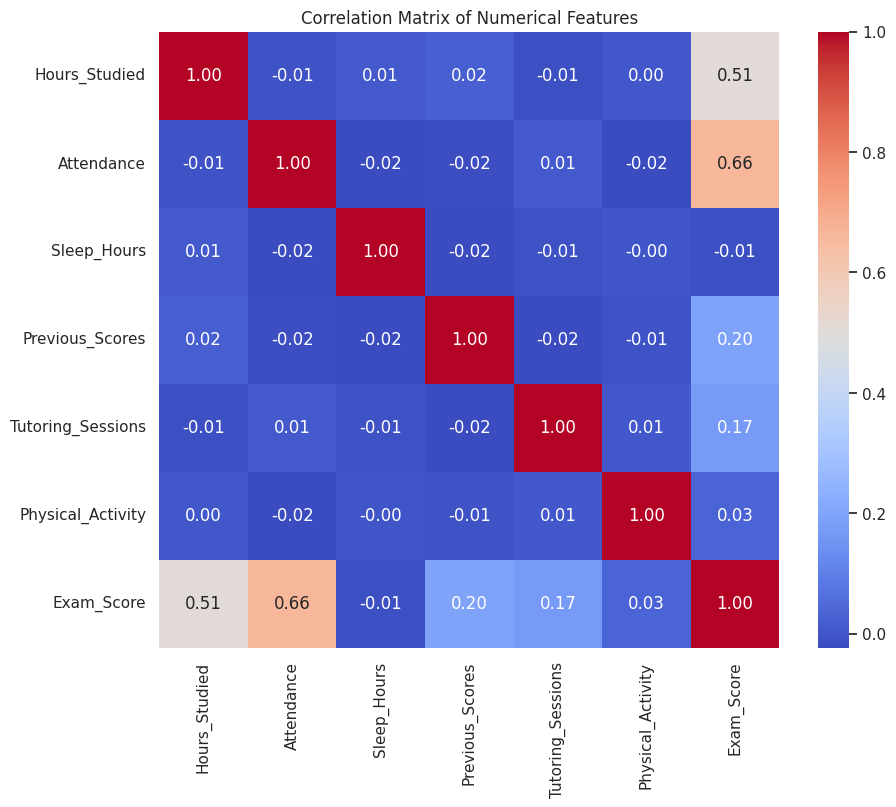

In [27]:
# Task 5: Apply PCA if numerical features show correlation

# Check correlation: Calculate the correlation matrix for the numerical columns
correlation_matrix = df_remove[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Explained Variance Ratio: [0.83095898 0.16904102]


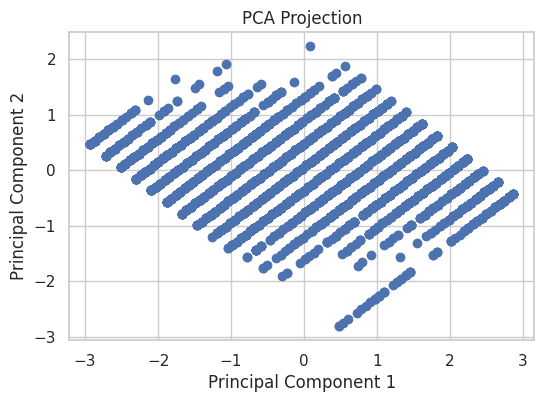

In [28]:
# Since Attendance and Exam scores show a correlation of 0.66 (moderately strong positive)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Using the Z-score
X = df_zscore_scaled[['Attendance', 'Exam_Score']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()